In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# <h4> Business Metrics and Geographic Analysis
<font size="2"> This notebook examines key business metrics in the Olist marketplace, including category-level, sales performance, the relatioship between delivery performance and customer satisfaction, and the geographic distribution of sales across Brazil.

<font size="4"> Load data

In [3]:
orders_items = pd.read_csv("../Data/Raw/olist_order_items_dataset.csv")
products = pd.read_csv("../Data/Raw/olist_products_dataset.csv")
category_translation = pd.read_csv("../Data/Raw/product_category_name_translation.csv")
delivered_orders = pd.read_csv('../Data/Processed/delivered_orders.csv')
sales = pd.read_csv('../Data/Processed/sales.csv')
customers = pd.read_csv("../Data/Raw/olist_customers_dataset.csv")
geo = pd.read_csv("../Data/Raw/olist_geolocation_dataset.csv")


reviews = pd.read_csv("../Data/Raw/olist_order_reviews_dataset.csv")
date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date'
                ]

for col in date_columns:
    delivered_orders[col] =pd.to_datetime(delivered_orders[col])

<font size="4"> Build product- category sales table

In [4]:

items_products = orders_items.merge(
    products,
    on= 'product_id',
    how= 'left'
)
items_products = items_products.merge(
    category_translation,
    on= 'product_category_name',
    how='left'
    )

<font size="4">Category-levels sales performance <br>
<font size="2">This section aggreggates total revenue and items sold by product category to identify the strongest-performing segments in the marketplace.

In [5]:
category_sales = items_products.groupby(
    'product_category_name_english'
).agg(
    revenue = ('price', 'sum'),
    items_sold = ('order_item_id', 'count')
).sort_values('revenue', ascending=False)
category_sales.head(10)

,revenue,items_sold
product_category_name_english,,
health_beauty,1258681.34,9670
watches_gifts,1205005.68,5991
bed_bath_table,1036988.68,11115
sports_leisure,988048.97,8641
computers_accessories,911954.32,7827
furniture_decor,729762.49,8334
cool_stuff,635290.85,3796
housewares,632248.66,6964
auto,592720.11,4235


<font size="2"> Conclusion: Category-level aggregation makes it possible to distinguish between categories that generate the highest revenue and those that sell the largest number of items.

<font size="4">Top categories by revenue

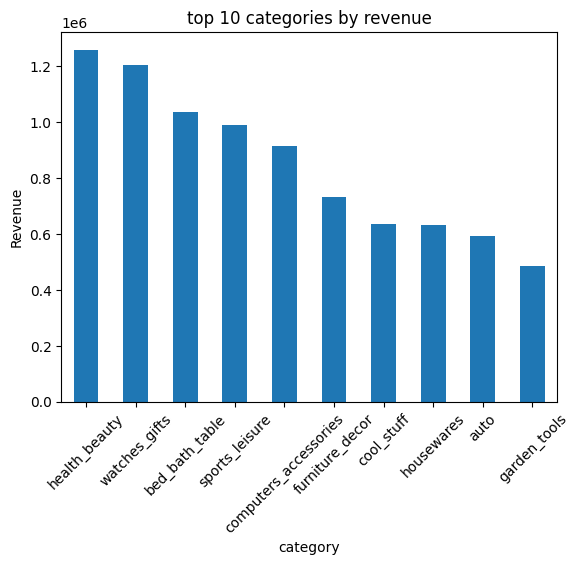

In [6]:
top10 = category_sales.head(10)
top10['revenue'].plot(kind='bar')
plt.title('top 10 categories by revenue')  
plt.xlabel('category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show() 

<font size="2"> Conclusion: Revenue is concentrated in a limit gruop of categories, with Helath & Beauty standing out as one of the strongest contributior.

<font size="4"> Top categories by sales volume <br>
<font size="2"> The following chart shows the categories with the highest number of items sold.

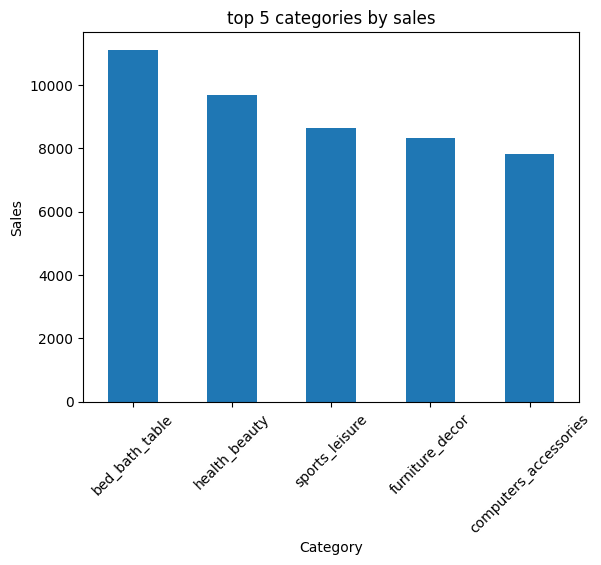

In [7]:
top5_sold = category_sales['items_sold'].sort_values(ascending=False).head(5)
top5_sold.plot(kind='bar')
plt.title('top 5 categories by sales')  
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show() 

<font size="4"> Category insights

<font size="2">

- Health & Beauty appears as one of the leading categories in terms of revenue generation.
- Bed Bath Table shows strong sales volume, but high volume does not always imply the highest revenue.
- Some categories are driven by quantity sold, while others are driven by higher-value products.

<font size="4"> Delivery performance and customer satisfaction

<font size="4">Build review-delivery dataset

In [8]:
reviews_orders = reviews.merge(
    delivered_orders,
    on= 'order_id',
    how= 'inner'                
    )

<font size="4"> Average review score

In [9]:
print(f"Average review score: {reviews_orders['review_score'].mean():.2%}")

Average review score: 415.57%


<font size="2">Conclusion: The average review score provides a baseline for interpreting whether delayed orders perform above or below the general satisfaction level.

<font size="4"> Review score by delivery performance <br>
<font size="2">This section compares the average review score between orders delivered on time and orders delivered late.

In [10]:

reviews_orders.groupby('on_time')['review_score'].mean().rename({
    0: 'Delayed',
    1: 'On time'
})

on_time
Delayed    2.273804
On time    4.289980
Name: review_score, dtype: float64

<font size="2"> Conclusion: Orders delivered on time trend to receive substantially higher review score than delayed orders, suggesting that logistics performance has a direct impact on customer satisfaction.

<font size="4">Review score distribution 

In [11]:
reviews_orders['review_score'].value_counts().sort_index()

review_score
1     9406
2     2941
3     7961
4    18987
5    57066
Name: count, dtype: int64

<font size="4"> Reviews score by on-time status <br>
<font size="2"> The following boxplot compares the distribution of review scores for on-time and delayed orders.

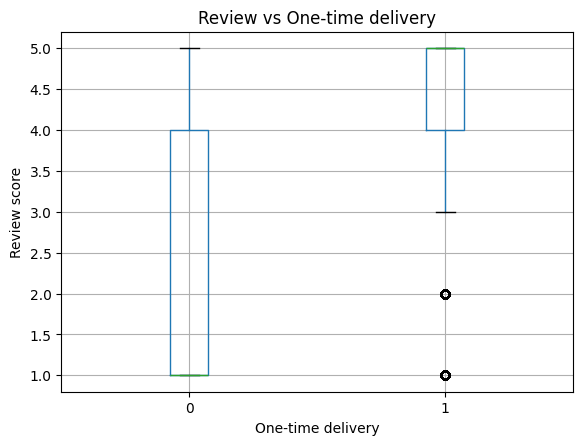

In [12]:
reviews_orders.boxplot(
    column='review_score',
    by='on_time'
)
plt.title('Review vs One-time delivery')
plt.suptitle('')
plt.xlabel('One-time delivery')
plt.ylabel('Review score')
plt.show()

<font size="2"> Satisfaction impact of delivery delays

Delayed orders are associated with a strong drop in customer satisfaction. Orders delivered on time have an average review score of approximately 4.29, while delayed orders average around 2.77. This gap suggests that delivery reliability is not only an operational metric, but also a major driver of customer experience and perceived service quality.

**Key insight:** Reducing delivery delays could have a significant positive effect on customer satisfaction.

<font size="4"> Geographic sales analysis by state

<font size="4">Build customers-sales table

In [13]:
sales_customers = sales.merge(
    customers,
    on='customer_id',
    how='left'
)
sales_customers.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,on_time,total_price,total_freight,total_items,total_revenue,month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,1,29.99,8.72,1,38.71,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,1,118.70,22.76,1,141.46,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,1,159.90,19.22,1,179.12,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,1,45.00,27.20,1,72.20,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,1,19.90,8.72,1,28.62,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


<font size="4"> Revenue and orders by satate

In [14]:
state_sales = sales_customers.groupby(
    'customer_state'
).agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'count')
).sort_values('revenue', ascending=False)

state_sales.head(10)

,revenue,orders
customer_state,,
SP,5769703.15,40501
RJ,2055401.57,12350
MG,1818891.67,11354
RS,861472.79,5345
PR,781708.80,4923
SC,595127.78,3546
BA,591137.81,3256
DF,346123.35,2080
GO,334212.35,1957


<font size="2"> Conclusion: State-level aggregation reveals the main regional amrkets in terms of both transaction volume and revenue genmeration.

<font size="4"> Top states bt revenue

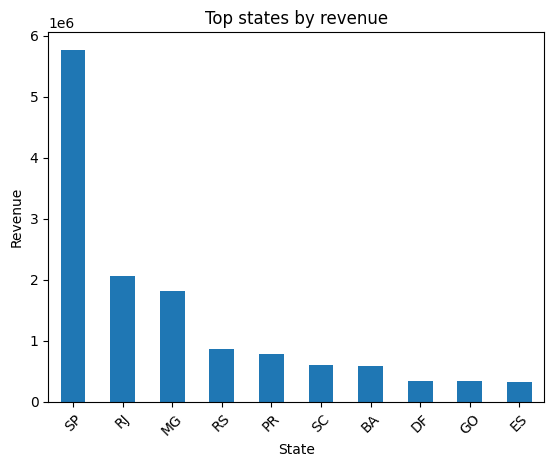

In [15]:
top_sales = state_sales.head(10)
top_sales['revenue'].plot(kind='bar')
plt.title('Top states by revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

<font size="2"> Conclusion: Revenue is concentrated in a small gropu of states, with the Southeast region showing the strongest commercial presence.

<font size="4"> Top states by number of orders

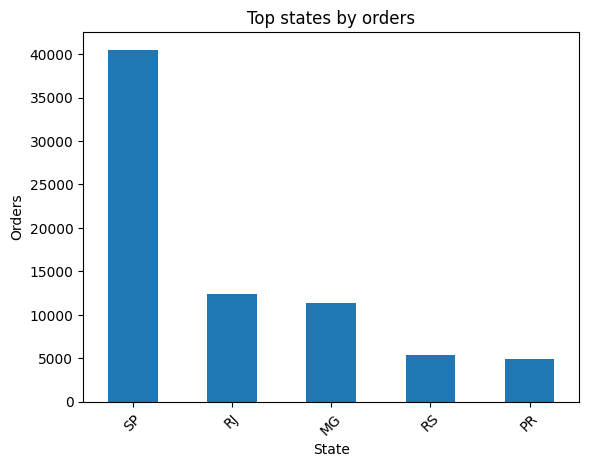

In [16]:
top5_orders = state_sales['orders'].sort_values(ascending=False).head(5)
top5_orders.plot(kind='bar')
plt.title('Top states by orders')
plt.xlabel('State')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.show()

<h6> Las ventas se concentran principalmente en los estados del sureste de Brasil, especialemte en sao paulo, que  lidera tanto en ingresos como en pedidos. Refleja la densidad poblacional y el desarrollo de la región

<font size="4"> Geospatial distribution of orders<br>
<font size="2"> This section moves from state-level analysis to more granular geographic perspective by mapping orders according to customer zip code and geolocation coordinates.

<font size="4"> Agregate sales by zip code prefix

<font size="4">Marge sales with geolocation data

In [17]:

geo_sales = sales_customers.groupby(
    'customer_zip_code_prefix'
).agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()

In [18]:
geo_map = geo_sales.merge(
    geo,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

<font size="4"> Aggregate by geographic coordiantes <br>
<font size="2"> This step groups observations by latitude and longitude in order to prepare the saptial visualization.

In [19]:

geo_map = geo_map.groupby(
    ['geolocation_lat', 'geolocation_lng']
).agg(
    revenue=('revenue', 'sum'),
    orders =('orders', 'sum')
).reset_index()

<font size="4"> Geographic dsitribution of orders

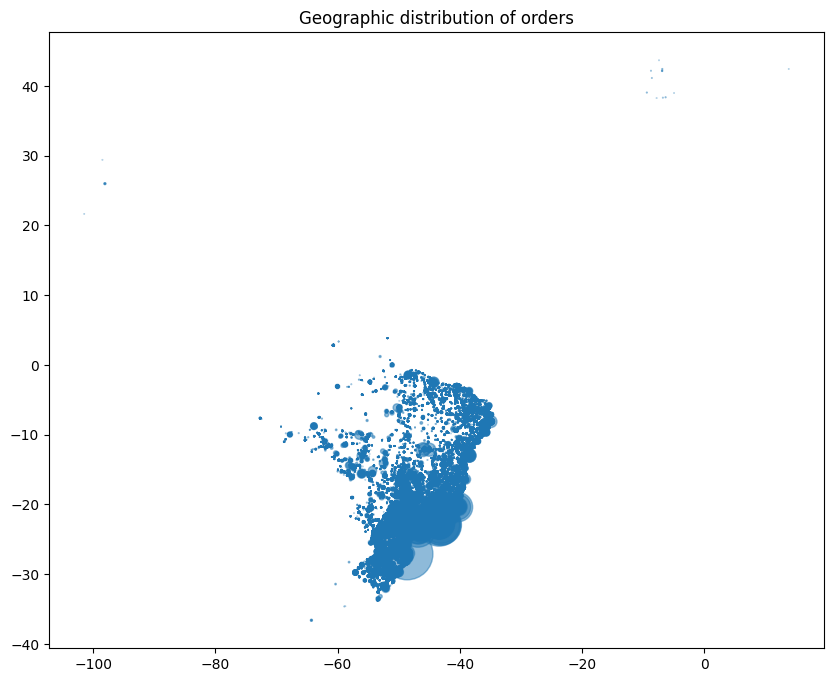

In [21]:
plt.figure(figsize=(10,8))

plt.scatter(
    geo_map["geolocation_lng"],
    geo_map["geolocation_lat"],
    s=geo_map["orders"]/10,
    alpha=0.5
)

plt.title("Geographic distribution of orders")

plt.show()

<font size="4">
Final conclusions

- Revenue and sales volume are concentrated in a relatively small group of product categories.
- Delivery performance has a strong relationship with customer satisfaction, as delayed orders receive significantly lower review scores.
- Sales are geographically concentrated, especially in southeastern Brazil, with São Paulo standing out as the leading market.
- The geospatial analysis confirms that order density is not uniform, but clustered in the country’s most commercially active regions.

Overall, the notebook shows that category performance, logistics reliability, and geographic concentration are key dimensions for understanding marketplace performance.